AI-powered Multi-Agent Data Preprocessing System using LangGraph + LangChain + LLM (OpenAI/Groq)

In [1]:
# =========================================================
# Install Required Libraries (Run Once in Colab)
# =========================================================

!pip -q install langgraph langchain langchain-groq rich python-dotenv scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.8 MB/s eta 0:00:00


In [2]:
# =========================================================
# Imports
# =========================================================

import io
import sys
import pandas as pd
import numpy as np

from typing import TypedDict, List

from sklearn.ensemble import IsolationForest

from google.colab import userdata

from langchain_groq import ChatGroq

from langgraph.graph import StateGraph, END

from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich.syntax import Syntax
from rich import box

In [3]:
# =========================================================
# Rich Console
# =========================================================

console = Console()

In [4]:
# =========================================================
# Load Dataset
# =========================================================

# Upload dataset.csv to Colab before running

df = pd.read_csv("dataset.csv")

console.print(
    "\n[bold green]✓ Dataset Loaded Successfully[/bold green]\n"
)

✓ Dataset Loaded Successfully

In [5]:
# =========================================================
# Dataset Preview
# =========================================================

preview_table = Table(
    title="Original Dataset Preview",
    box=box.DOUBLE_EDGE
)

for col in df.columns:
    preview_table.add_column(col)

for _, row in df.head().iterrows():
    preview_table.add_row(*[str(i) for i in row])

console.print(preview_table)

                   Original Dataset Preview                    
╔════════════╤═════════╤══════════╤═══════════════╤═══════════╗
║ date       │ sku     │ location │ quantity_sold │ inventory ║
╟────────────┼─────────┼──────────┼───────────────┼───────────╢
║ 2024-01-01 │ SKU_101 │ Chennai  │ 52.0          │ 120       ║
║ 2024-01-02 │ SKU_101 │ Chennai  │ 49.0          │ 115       ║
║ 2024-01-03 │ SKU_101 │ Chennai  │ nan           │ 110       ║
║ 2024-01-04 │ SKU_101 │ Chennai  │ 55.0          │ 105       ║
║ 2024-01-05 │ SKU_101 │ Chennai  │ 60.0          │ 100       ║
╚════════════╧═════════╧══════════╧═══════════════╧═══════════╝

In [6]:
# =========================================================
# Dataset Information
# =========================================================

console.print(
    f"\n[bold cyan]Rows    : {df.shape[0]}[/bold cyan]"
)

console.print(
    f"[bold cyan]Columns : {df.shape[1]}[/bold cyan]"
)

console.print(
    f"[bold cyan]Column Names : {list(df.columns)}[/bold cyan]\n"
)

Rows    : 30

Columns : 5

Column Names : ['date', 'sku', 'location', 'quantity_sold', 'inventory']

In [7]:
# =========================================================
# Groq API
# =========================================================

GROQ_API_KEY = userdata.get("GROQ_API_KEY")

In [8]:
# =========================================================
# Initialize LLM
# =========================================================

llm = ChatGroq(

    api_key=GROQ_API_KEY,

    model_name="llama-3.3-70b-versatile",

    temperature=0
)

In [9]:
model_name="openai/gpt-oss-120b"

In [10]:
# =========================================================
# Data Preprocessing Tasks
# =========================================================

tasks = [

    "Display the entire dataset",

    "Print number of rows, number of columns and column names",

    "Identify and print quantitative and qualitative columns",

    "Detect missing values, print number of missing values and handle them",

    "Detect outliers, print high and low outliers and handle them using IQR",

    "Find duplicates and print number of duplicate rows and remove duplicates"

]

In [11]:
# =========================================================
# LangGraph State
# =========================================================

class AgentState(TypedDict):

    df: pd.DataFrame

    tasks: List[str]

    current_task_index: int

    current_task: str

    generated_code: str

    execution_output: str

In [12]:
# =========================================================
# Initial State
# =========================================================

initial_state = {

    "df": df,

    "tasks": tasks,

    "current_task_index": 0,

    "current_task": "",

    "generated_code": "",

    "execution_output": ""

}

Installation, imports, dataset loading, Groq setup, tasks, and LangGraph state.

Multi-Agent Implementation

In [13]:
# =========================================================
# Agent 1 : Guiding Agent
# =========================================================

def guiding_agent(state: AgentState):

    task_index = state["current_task_index"]

    task = state["tasks"][task_index]

    console.print(
        f"\n[bold magenta]"
        f"{'='*60}\n"
        f"Iteration {task_index + 1}\n"
        f"{'='*60}"
        f"[/bold magenta]"
    )

    console.print(
        f"[bold blue]Guiding Agent[/bold blue] → {task}"
    )

    return {

        "current_task": task

    }

Multi-Agent Implementation

In [14]:
# =========================================================
# Agent 2 : Coding Agent
# =========================================================

def coder_agent(state: AgentState):

    task = state["current_task"]

    prompt = f"""
You are an expert Python Data Engineer.

Dataset is already loaded as:

df

Rules:

1. Return ONLY executable Python code.
2. Do not explain anything.
3. Never reload the dataset.
4. Modify df directly.
5. Always print useful outputs.
6. Use pandas and numpy only.
7. Use IQR method for outliers.
8. Remove duplicate rows if found.

Task:

{task}

Return only Python code.
"""

    response = llm.invoke(prompt)

    code = response.content.strip()

    if "```python" in code:
        code = code.split("```python")[1]

    if "```" in code:
        code = code.split("```")[0]

    code = code.strip()

    console.print(
        "\n[bold yellow]Generated Python Code[/bold yellow]\n"
    )

    syntax = Syntax(
        code,
        "python",
        theme="monokai",
        line_numbers=True
    )

    console.print(syntax)

    return {

        "generated_code": code

    }

In [15]:
# =========================================================
# Agent 3 : Executor Agent
# =========================================================

def executor_agent(state: AgentState):

    df = state["df"]

    code = state["generated_code"]

    try:

        local_vars = {

            "df": df.copy(),

            "pd": pd,

            "np": np,

            "IsolationForest": IsolationForest

        }

        buffer = io.StringIO()

        sys.stdout = buffer

        exec(code, globals(), local_vars)

        sys.stdout = sys.__stdout__

        updated_df = local_vars.get("df", df)

        output = buffer.getvalue()

        console.print(

            Panel(

                output if output else "Execution Completed Successfully",

                title="Execution Output",

                style="bold cyan"

            )

        )

        return {

            "df": updated_df,

            "execution_output": output

        }

    except Exception as e:

        sys.stdout = sys.__stdout__

        console.print(

            Panel(

                str(e),

                title="Execution Error",

                style="bold red"

            )

        )

        return {

            "df": df,

            "execution_output": str(e)

        }

In [16]:
# =========================================================
# Agent 4 : Checker Agent
# =========================================================

def checker_agent(state: AgentState):

    current = state["current_task_index"]

    total = len(state["tasks"])

    if current < total - 1:

        console.print(

            "\n[bold cyan]Checker Agent → Task Completed ✓[/bold cyan]"

        )

        console.print(

            "[bold yellow]Proceeding to Next Task...[/bold yellow]"

        )

    else:

        console.print(

            "\n[bold green]Checker Agent → All Tasks Completed ✓[/bold green]"

        )

    return {}

In [17]:
# =========================================================
# Increment Task
# =========================================================

def increment_task(state: AgentState):

    return {

        "current_task_index":

        state["current_task_index"] + 1

    }

In [18]:
# =========================================================
# Router
# =========================================================

def router(state: AgentState):

    if state["current_task_index"] >= len(state["tasks"]):

        return END

    return "guiding_agent"

| Agent              | Responsibility                                                            |
| ------------------ | ------------------------------------------------------------------------- |
| **Guiding Agent**  | Selects the next preprocessing task.                                      |
| **Coding Agent**   | Uses the Groq LLM to generate Python code for the task.                   |
| **Executor Agent** | Executes the generated code on the DataFrame and captures printed output. |
| **Checker Agent**  | Confirms task completion and determines whether to continue.              |
| **Increment Task** | Moves to the next task index.                                             |
| **Router**         | Loops back to the Guiding Agent until all tasks are complete.             |


Build LangGraph, Execute and Save Dataset

In [20]:
# =========================================================
# Build LangGraph
# =========================================================

graph = StateGraph(AgentState)

In [21]:
# =========================================================
# Add Nodes
# =========================================================

graph.add_node("guiding_agent", guiding_agent)

graph.add_node("coder_agent", coder_agent)

graph.add_node("executor_agent", executor_agent)

graph.add_node("checker_agent", checker_agent)

graph.add_node("increment_task", increment_task)

In [22]:
# =========================================================
# Entry Point
# =========================================================

graph.set_entry_point("guiding_agent")

In [23]:
# =========================================================
# Add Edges
# =========================================================

graph.add_edge(
    "guiding_agent",
    "coder_agent"
)

graph.add_edge(
    "coder_agent",
    "executor_agent"
)

graph.add_edge(
    "executor_agent",
    "checker_agent"
)

graph.add_edge(
    "checker_agent",
    "increment_task"
)

In [24]:
# =========================================================
# Conditional Router
# =========================================================

graph.add_conditional_edges(

    "increment_task",

    router,

    {

        "guiding_agent": "guiding_agent",

        END: END

    }

)

In [25]:
# =========================================================
# Compile Graph
# =========================================================

app = graph.compile()

console.print(
    "\n[bold green]✓ LangGraph Compiled Successfully[/bold green]\n"
)

✓ LangGraph Compiled Successfully

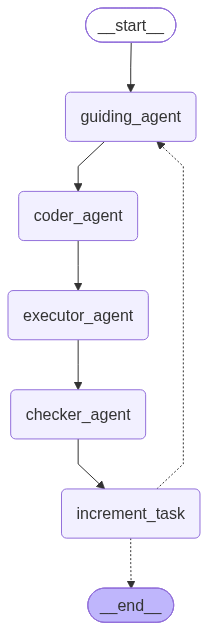

In [26]:
# =========================================================
# Display Mermaid Graph (Optional)
# =========================================================

try:

    from IPython.display import Image, display

    display(

        Image(

            app.get_graph().draw_mermaid_png()

        )

    )

except Exception as e:

    console.print(e)

In [27]:
# =========================================================
# Execute Workflow
# =========================================================

console.print(
    "\n[bold magenta]"
    "Starting Multi-Agent Data Preprocessing Workflow..."
    "[/bold magenta]\n"
)

final_state = app.invoke(

    initial_state,

    config={
        "recursion_limit":100
    }

)

Starting Multi-Agent Data Preprocessing Workflow...

============================================================
Iteration 1
============================================================

Guiding Agent → Display the entire dataset

Generated Python Code

  1 import pandas as pd                                                                                            
  2 import numpy as np                                                                                             
  3                                                                                                                
  4 print(df)                                                                                                      

...

Guiding Agent → Find duplicates and print number of duplicate rows and remove duplicates

Generated Python Code

   1 import pandas as pd                                                                                           
   2 import numpy as np                                                                                            
   3                                                                                                               
   4 # Find duplicates                                                                                             
   5 duplicates = df.duplicated().sum()                                                                            
   6                                                                                                               
   7 # Print number of duplicate rows                                                                              
   8 print(f"Number of duplicate rows: {duplicates}")                                                              
   9                                                                                                               
  10 # Remove duplicates                                                                                           
  11 df.drop_duplicates(inplace=True)                                                                              
  12                                                                                                               
  13 # Print updated shape of dataframe                                                                            
  14 print(f"Updated shape of dataframe: {df.shape}")                                                              
  15                                                                                                               
  16 # Print updated dataframe                                                                                     
  17 print(df.head())                                                                                              

╭─────────────────────────────────────────────── Execution Output ────────────────────────────────────────────────╮
│ Number of duplicate rows: 0                                                                                     │
│ Updated shape of dataframe: (30, 5)                                                                             │
│          date      sku location  quantity_sold  inventory                                                       │
│ 0  2024-01-01  SKU_101  Chennai      52.000000        120                                                       │
│ 1  2024-01-02  SKU_101  Chennai      49.000000        115                                                       │
│ 2  2024-01-03  SKU_101  Chennai      81.964286        110                                                       │
│ 3  2024-01-04  SKU_101  Chennai      55.000000        105                                                       │
│ 4  2024-01-05  SKU_101  Chennai      60.000000        100                                                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Checker Agent → All Tasks Completed ✓

In [28]:
# =========================================================
# Final DataFrame
# =========================================================

final_df = final_state["df"]

console.print(
    "\n[bold green]"
    "✓ Final Dataset Generated Successfully"
    "[/bold green]\n"
)

✓ Final Dataset Generated Successfully

In [29]:
# =========================================================
# Display Final Dataset
# =========================================================

final_table = Table(

    title="Final Processed Dataset",

    box=box.DOUBLE_EDGE

)

for col in final_df.columns:

    final_table.add_column(col)

for _, row in final_df.iterrows():

    final_table.add_row(

        *[str(i) for i in row]

    )

console.print(final_table)

                      Final Processed Dataset                      
╔════════════╤═════════╤══════════╤═══════════════════╤═══════════╗
║ date       │ sku     │ location │ quantity_sold     │ inventory ║
╟────────────┼─────────┼──────────┼───────────────────┼───────────╢
║ 2024-01-01 │ SKU_101 │ Chennai  │ 52.0              │ 120       ║
║ 2024-01-02 │ SKU_101 │ Chennai  │ 49.0              │ 115       ║
║ 2024-01-03 │ SKU_101 │ Chennai  │ 81.96428571428571 │ 110       ║
║ 2024-01-04 │ SKU_101 │ Chennai  │ 55.0              │ 105       ║
║ 2024-01-05 │ SKU_101 │ Chennai  │ 60.0              │ 100       ║
║ 2024-01-06 │ SKU_101 │ Chennai  │ -5.0              │ 95        ║
║ 2024-01-07 │ SKU_101 │ Chennai  │ 58.0              │ 90        ║
║ 2024-01-08 │ SKU_101 │ Chennai  │ 62.0              │ 85        ║
║ 2024-01-09 │ SKU_101 │ Chennai  │ 59.0              │ 80        ║
║ 2024-01-10 │ SKU_101 │ Chennai  │ 57.0              │ 75        ║
║ 2024-01-11 │ SKU_101 │ Chennai  │ 300.0             │ 70        ║
║ 2024-01-12 │ SKU_101 │ Chennai  │ 56.0              │ 65        ║
║ 2024-01-13 │ SKU_101 │ Chennai  │ 54.0              │ 60        ║
║ 2024-01-14 │ SKU_101 │ Chennai  │ 2.0               │ 55        ║
║ 2024-01-15 │ SKU_101 │ Chennai  │ 53.0              │ 50        ║
║ 2024-01-16 │ SKU_101 │ Chennai  │ 61.0              │ 45        ║
║ 2024-01-17 │ SKU_101 │ Chennai  │ 63.0              │ 40        ║
║ 2024-01-18 │ SKU_101 │ Chennai  │ 65.0              │ 35        ║
║ 2024-01-19 │ SKU_101 │ Chennai  │ 81.96428571428571 │ 30        ║
║ 2024-01-20 │ SKU_101 │ Chennai  │ 64.0              │ 25        ║
║ 2024-01-21 │ SKU_101 │ Chennai  │ 70.0              │ 20        ║
║ 2024-01-22 │ SKU_101 │ Chennai  │ 72.0              │ 15        ║
║ 2024-01-23 │ SKU_101 │ Chennai  │ 68.0              │ 10        ║
║ 2024-01-24 │ SKU_101 │ Chennai  │ 500.0             │ 5         ║
║ 2024-01-25 │ SKU_101 │ Chennai  │ 66.0              │ 0         ║
║ 2024-01-26 │ SKU_101 │ Chennai  │ 67.0              │ 0         ║
║ 2024-01-27 │ SKU_101 │ Chennai  │ 69.0              │ 0         ║
║ 2024-01-28 │ SKU_101 │ Chennai  │ 71.0              │ 10        ║
║ 2024-01-29 │ SKU_101 │ Chennai  │ 73.0              │ 15        ║
║ 2024-01-30 │ SKU_101 │ Chennai  │ 74.0              │ 20        ║
╚════════════╧═════════╧══════════╧═══════════════════╧═══════════╝

In [30]:
# =========================================================
# Dataset Summary
# =========================================================

console.print(
    "\n[bold cyan]Dataset Summary[/bold cyan]\n"
)

console.print(
    f"Rows      : {final_df.shape[0]}"
)

console.print(
    f"Columns   : {final_df.shape[1]}"
)

console.print(
    f"Features  : {list(final_df.columns)}"
)

Dataset Summary

Rows      : 30

Columns   : 5

Features  : ['date', 'sku', 'location', 'quantity_sold', 'inventory']

In [34]:
# =========================================================
# Save Final Dataset
# =========================================================

output_file = "Final_Dataset.csv"

final_df.to_csv(

    output_file,

    index=False

)

console.print(

    f"\n[bold green]✓ Final dataset saved as {output_file}[/bold green]"

)

✓ Final dataset saved as Final_Dataset.csv

In [35]:
# =========================================================
# Download Dataset (Google Colab)
# =========================================================

from google.colab import files

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

                  dataset.csv
                       │
                       ▼
          Load Dataset into Pandas
                       │
                       ▼
        ┌──────────────────────────┐
        │      Guiding Agent       │
        │ Select Next Task         │
        └─────────────┬────────────┘
                      │
                      ▼
        ┌──────────────────────────┐
        │      Coding Agent        │
        │ Groq Generates Code      │
        └─────────────┬────────────┘
                      │
                      ▼
        ┌──────────────────────────┐
        │     Executor Agent       │
        │ Execute Generated Code   │
        └─────────────┬────────────┘
                      │
                      ▼
        ┌──────────────────────────┐
        │      Checker Agent       │
        │ Verify Task Completion   │
        └─────────────┬────────────┘
                      │
            More Tasks?
             │        │
            Yes       No
             │        │
             ▼        ▼
      Guiding Agent  Save Final_Dataset.csv

Building the LangGraph

Adding nodes and edges

Compiling the graph

Displaying the Mermaid workflow

Running the multi-agent pipeline

Showing the final cleaned dataset

Saving Final_Dataset.csv